In [5]:
from pathlib import Path

from allensdk.brain_observatory.ecephys.ecephys_project_cache import (
    EcephysProjectCache,
)

cache_dir = Path("./data/allen_cache").resolve()
manifest_path = cache_dir / "manifest.json"

cache = EcephysProjectCache.from_warehouse(
    manifest=str(manifest_path)
)

print("Manifest:", manifest_path)

sessions = cache.get_session_table()

print("Number of sessions:", len(sessions))
display(sessions.head())

Manifest: /Users/ricky/Library/Mobile Documents/com~apple~CloudDocs/Intern/ABIC implemented/VisionRecon/data/allen_cache/manifest.json
Number of sessions: 58


,published_at,specimen_id,session_type,age_in_days,sex,full_genotype,unit_count,channel_count,probe_count,ecephys_structure_acronyms
id,,,,,,,,,,
715093703,2019-10-03T00:00:00Z,699733581,brain_observatory_1.1,118.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,884,2219,6,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,2019-10-03T00:00:00Z,703279284,brain_observatory_1.1,122.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,755,2214,6,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,2019-10-03T00:00:00Z,707296982,brain_observatory_1.1,125.0,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,444,2229,6,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,2019-10-03T00:00:00Z,717038288,brain_observatory_1.1,100.0,M,wt/wt,824,1847,5,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,2019-10-03T00:00:00Z,718643567,brain_observatory_1.1,108.0,M,wt/wt,568,2218,6,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"


In [6]:
selected_session_ids = [
    732592105,
    797828357,
    755434585,
    756029989,
    791319847,
]

session_id = selected_session_ids[0]

session = cache.get_session_data(session_id)

print("Loaded session:", session_id)
print(type(session))

stimulus_presentations = session.stimulus_presentations.copy()

print("Number of stimulus presentations:", len(stimulus_presentations))

print(
    stimulus_presentations["stimulus_name"]
    .value_counts(dropna=False)
)

/opt/anaconda3/envs/allen-vc/lib/python3.11/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/anaconda3/envs/allen-vc/lib/python3.11/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


Loaded session: 732592105
<class 'allensdk.brain_observatory.ecephys.ecephys_session.EcephysSession'>
Number of stimulus presentations: 70388
natural_movie_three    36000
natural_movie_one      18000
static_gratings         6000
natural_scenes          5950
gabors                  3645
drifting_gratings        628
flashes                  150
spontaneous               15
Name: stimulus_name, dtype: int64


In [7]:
natural_scenes = stimulus_presentations[
    stimulus_presentations["stimulus_name"] == "natural_scenes"
].copy()

display(natural_scenes.head())

print(
    natural_scenes["frame"]
    .value_counts()
    .sort_index()
)

,stimulus_block,start_time,stop_time,stimulus_name,color,y_position,orientation,frame,phase,temporal_frequency,x_position,spatial_frequency,contrast,size,duration,stimulus_condition_id
stimulus_presentation_id,,,,,,,,,,,,,,,,
51353,9.0,5900.690484,5900.940697,natural_scenes,null,null,null,4.0,null,null,null,null,null,null,0.250213,4908
51354,9.0,5900.940697,5901.190910,natural_scenes,null,null,null,48.0,null,null,null,null,null,null,0.250213,4909
51355,9.0,5901.190910,5901.441123,natural_scenes,null,null,null,75.0,null,null,null,null,null,null,0.250213,4910
51356,9.0,5901.441123,5901.691336,natural_scenes,null,null,null,3.0,null,null,null,null,null,null,0.250213,4911
51357,9.0,5901.691336,5901.941540,natural_scenes,null,null,null,102.0,null,null,null,null,null,null,0.250205,4912


-1.0      50
 0.0      50
 1.0      50
 2.0      50
 3.0      50
          ..
 113.0    50
 114.0    50
 115.0    50
 116.0    50
 117.0    50
Name: frame, Length: 119, dtype: int64


In [8]:
natural_scenes = natural_scenes[natural_scenes["frame"] >= 0].copy()

natural_scenes["frame"] = natural_scenes["frame"].astype(int)

print("Remaining trials:", len(natural_scenes))
print("Number of real images:", natural_scenes["frame"].nunique())
print("Trials per image:")
print(natural_scenes["frame"].value_counts().sort_index().head())

Remaining trials: 5900
Number of real images: 118
Trials per image:
0    50
1    50
2    50
3    50
4    50
Name: frame, dtype: int64


In [9]:
target_areas = ["VISp", "VISl", "VISpm"]

units = session.units.copy()

selected_units = units[
    units["ecephys_structure_acronym"].isin(target_areas)
].copy()

print("Selected units:", len(selected_units))

print(selected_units["ecephys_structure_acronym"].value_counts())

display(selected_units[["ecephys_structure_acronym", "firing_rate", "snr"]].head())

Selected units: 216
VISp     110
VISpm     66
VISl      40
Name: ecephys_structure_acronym, dtype: int64


,ecephys_structure_acronym,firing_rate,snr
unit_id,,,
915957872,VISpm,9.636760,2.661222
915957896,VISpm,1.114986,6.847745
915957941,VISpm,2.121415,4.765319
915957936,VISpm,5.329349,3.739058
915958814,VISpm,0.922304,2.003496


START TRAINING

In [225]:
import numpy as np

unit_ids = selected_units.index.to_numpy()

presentation_ids = natural_scenes.index.to_numpy()

time_bin_edges = np.array([0.0, 0.25])
#time_bin_edges = np.array([0.00,0.05,0.10,0.15,0.20,0.25])

spike_counts = session.presentationwise_spike_counts(
    bin_edges=time_bin_edges,
    stimulus_presentation_ids=presentation_ids,
    unit_ids=unit_ids,
)
print(spike_counts)
print("Dimensions:", spike_counts.dims)
print("Shape:", spike_counts.shape)

X = spike_counts.values[:, 0, :]
#X = spike_counts.values.reshape(spike_counts.shape[0],-1)

print("Spike counts shape:", spike_counts.shape)
print("X shape:", X.shape)
y = natural_scenes["frame"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique image classes:", len(np.unique(y)))

<xarray.DataArray 'spike_counts' (stimulus_presentation_id: 5900,
                                  time_relative_to_stimulus_onset: 1,
                                  unit_id: 216)>
array([[[4, 0, 1, ..., 1, 0, 0]],

       [[3, 1, 0, ..., 0, 2, 0]],

       [[9, 0, 0, ..., 0, 0, 0]],

       ...,

       [[2, 2, 0, ..., 0, 0, 0]],

       [[1, 2, 0, ..., 0, 0, 1]],

       [[1, 2, 0, ..., 0, 0, 0]]], dtype=uint16)
Coordinates:
  * stimulus_presentation_id         (stimulus_presentation_id) int64 51353 ....
  * time_relative_to_stimulus_onset  (time_relative_to_stimulus_onset) float64 ...
  * unit_id                          (unit_id) int64 915957872 ... 915963135
Dimensions: ('stimulus_presentation_id', 'time_relative_to_stimulus_onset', 'unit_id')
Shape: (5900, 1, 216)
Spike counts shape: (5900, 1, 216)
X shape: (5900, 216)
X shape: (5900, 216)
y shape: (5900,)
Unique image classes: 118


In [226]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("Training repetitions per image:")
print(np.unique(y_train, return_counts=True)[1][:5])

print("Testing repetitions per image:")
print(np.unique(y_test, return_counts=True)[1][:5])

Training shape: (4720, 216)
Testing shape: (1180, 216)
Training repetitions per image:
[40 40 40 40 40]
Testing repetitions per image:
[10 10 10 10 10]


In [227]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, top_k_accuracy_score

decoder = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            solver="lbfgs",
            penalty="l2",
            C=1.0,
            max_iter=3000,
            random_state=42
        )
    )
])

decoder.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [228]:
y_pred = decoder.predict(X_test)
y_probability = decoder.predict_proba(X_test)

top1_accuracy = accuracy_score(y_test, y_pred)

top5_accuracy = top_k_accuracy_score(
    y_test,
    y_probability,
    k=5,
    labels=decoder.classes_
)

chance_accuracy = 1 / len(np.unique(y))

print(f"Chance accuracy: {chance_accuracy:.4f}")
print(f"Top-1 accuracy: {top1_accuracy:.4f}")
print(f"Top-5 accuracy: {top5_accuracy:.4f}")

Chance accuracy: 0.0085
Top-1 accuracy: 0.6771
Top-5 accuracy: 0.8398


In [229]:
from pathlib import Path
import numpy as np
from PIL import Image

image_dir = Path("data/allen_cache/natural_scene_templates")

natural_scene_images = np.stack([
    np.array(Image.open(image_dir / f"natural_scene_{frame_id}.tiff"))
    for frame_id in range(118)
])

print("Loaded image shape:", natural_scene_images.shape)
print("Data type:", natural_scene_images.dtype)

Loaded image shape: (118, 918, 1174)
Data type: uint8


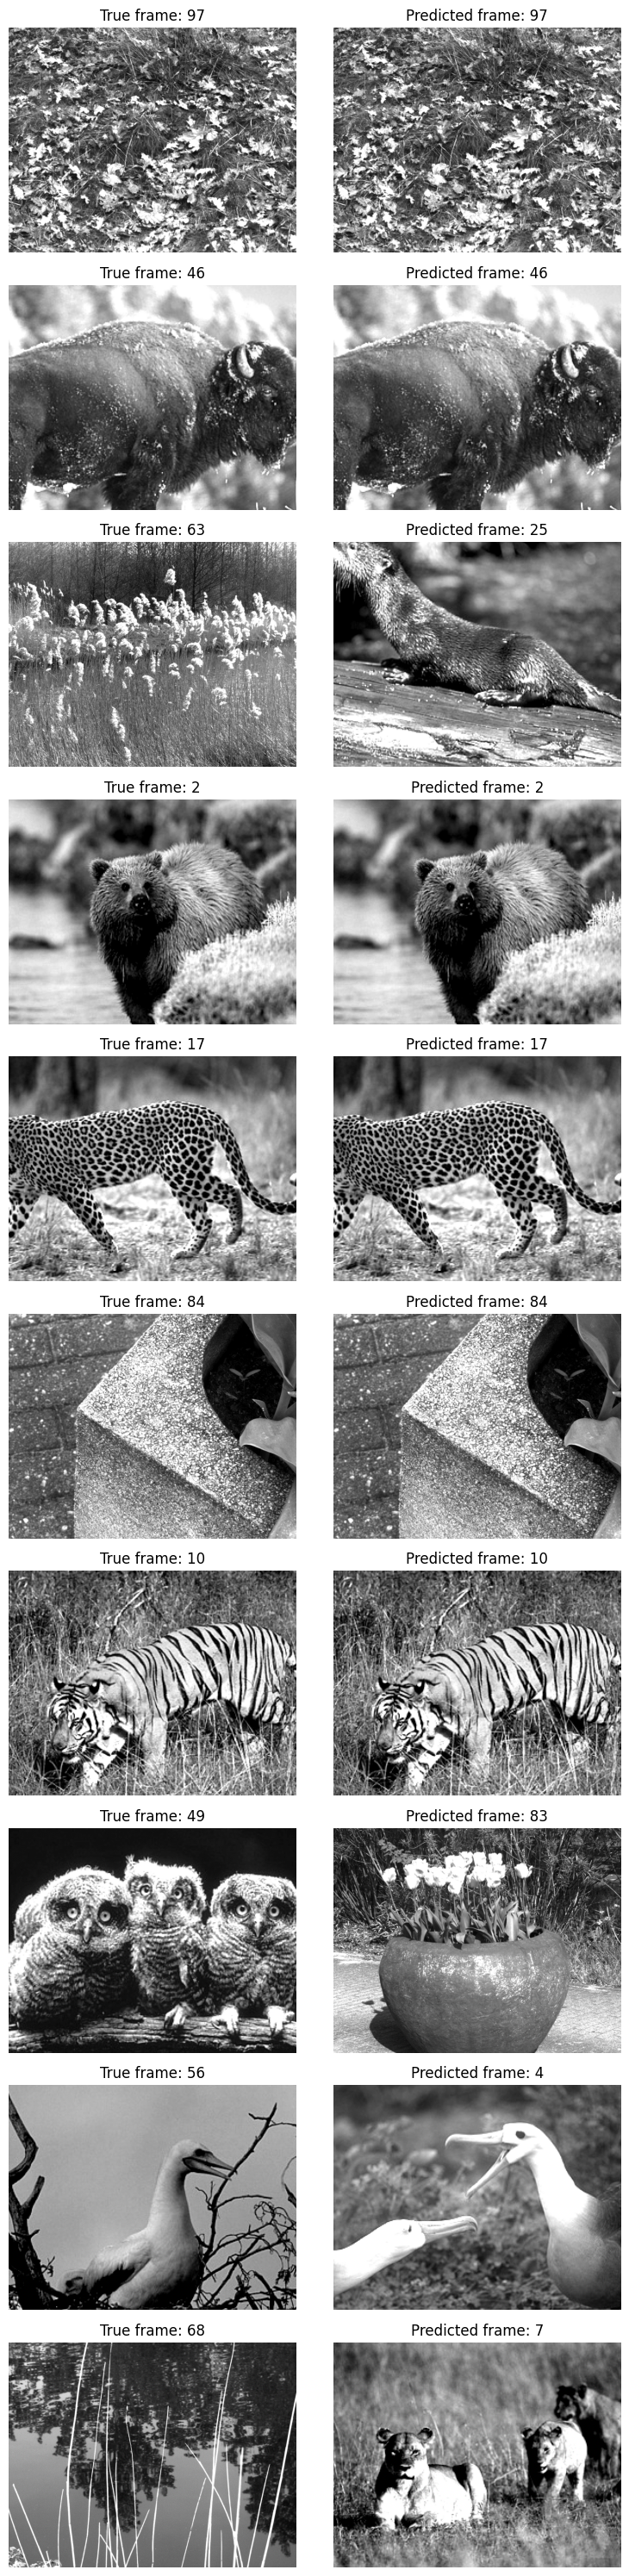

In [230]:
import matplotlib.pyplot as plt
import numpy as np

n_examples = 10
example_indices = np.random.default_rng(42).choice(
    len(y_test),
    size=n_examples,
    replace=False
)

fig, axes = plt.subplots(n_examples, 2, figsize=(8, 3 * n_examples))

for row, idx in enumerate(example_indices):
    true_frame = int(y_test[idx])
    predicted_frame = int(y_pred[idx])

    axes[row, 0].imshow(
        natural_scene_images[true_frame],
        cmap="gray"
    )
    axes[row, 0].set_title(f"True frame: {true_frame}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        natural_scene_images[predicted_frame],
        cmap="gray"
    )
    axes[row, 1].set_title(
        f"Predicted frame: {predicted_frame}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Start Reconstruction

In [231]:
from PIL import Image
import numpy as np

recon_shape = (32, 32)

small_scene_images = np.stack([
    np.array(Image.fromarray(image).resize(recon_shape))
    for image in natural_scene_images
])

print("Original shape:", natural_scene_images.shape)
print("Reconstruction target shape:", small_scene_images.shape)

Original shape: (118, 918, 1174)
Reconstruction target shape: (118, 32, 32)


In [232]:
small_scene_images = small_scene_images.astype(np.float32)

small_scene_images = (small_scene_images - small_scene_images.min()) / (small_scene_images.max() - small_scene_images.min())

print("Minimum:", small_scene_images.min())
print("Maximum:", small_scene_images.max())

Minimum: 0.0
Maximum: 1.0


In [233]:
from sklearn.decomposition import PCA

# Flatten each 32 × 32 image into a vector of length 1024
flat_scene_images = small_scene_images.reshape(118, -1)

print("Flattened image shape:", flat_scene_images.shape)

image_pca = PCA(
    n_components=100,
    random_state=42
)

scene_pca_features = image_pca.fit_transform(flat_scene_images)

print("PCA feature shape:", scene_pca_features.shape)
print(
    "Explained variance:",
    image_pca.explained_variance_ratio_.sum()
)

Flattened image shape: (118, 1024)
PCA feature shape: (118, 100)
Explained variance: 0.9879466


In [234]:
pca_reconstructed_flat = image_pca.inverse_transform(scene_pca_features)

pca_reconstructed_images = pca_reconstructed_flat.reshape(118, 32, 32)

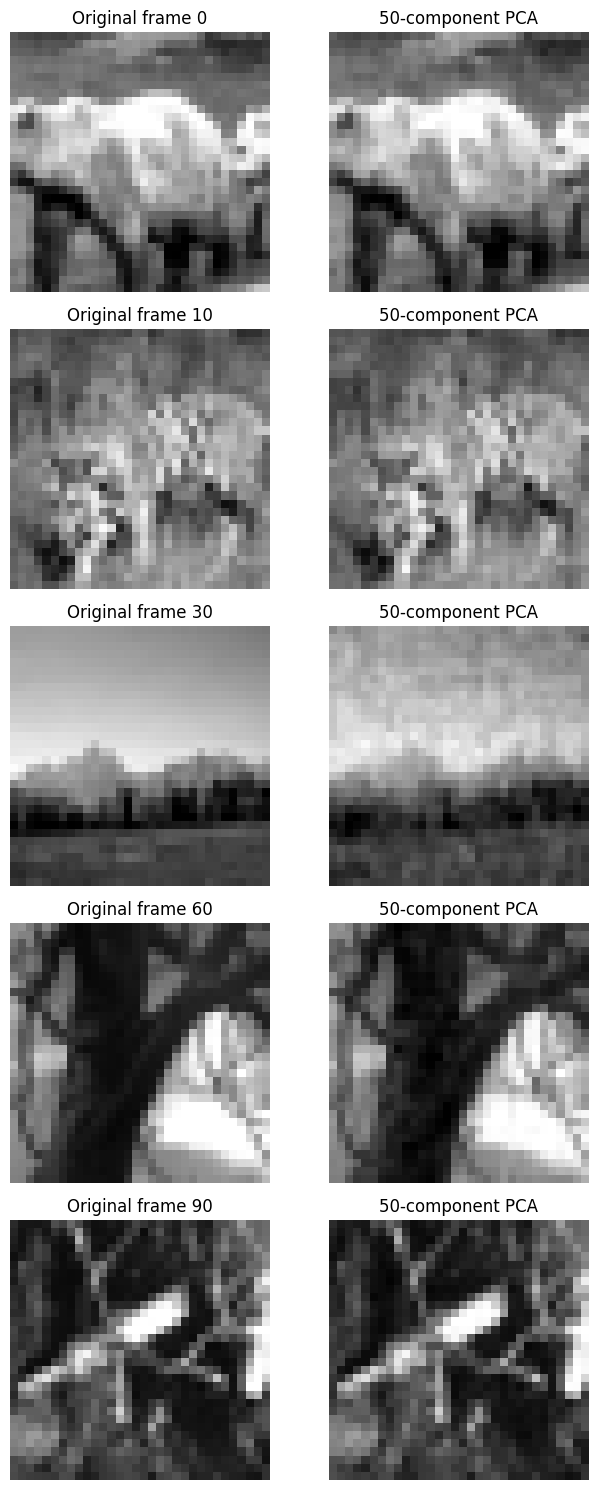

In [235]:
import matplotlib.pyplot as plt

frame_ids = [0, 10, 30, 60, 90]

fig, axes = plt.subplots(
    len(frame_ids),
    2,
    figsize=(7, 3 * len(frame_ids))
)

for row, frame_id in enumerate(frame_ids):
    axes[row, 0].imshow(
        small_scene_images[frame_id],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title(f"Original frame {frame_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        pca_reconstructed_images[frame_id],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 1].set_title("50-component PCA")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [236]:
#216 neural features->50 image PCA features (5900 images)
Y_train = scene_pca_features[y_train]
Y_test = scene_pca_features[y_test]

print("Neural training input:", X_train.shape)
print("PCA training target:", Y_train.shape)

print("Neural testing input:", X_test.shape)
print("PCA testing target:", Y_test.shape)

Neural training input: (4720, 216)
PCA training target: (4720, 100)
Neural testing input: (1180, 216)
PCA testing target: (1180, 100)


In [353]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

reconstruction_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "mlp",
        MLPRegressor(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            random_state=42,
            verbose=True
        )
    )
])

reconstruction_model.fit(X_train, Y_train)

Iteration 1, loss = 0.33356798
Validation score: -0.084936
Iteration 2, loss = 0.29413529
Validation score: -0.051524
Iteration 3, loss = 0.28745142
Validation score: -0.071043
Iteration 4, loss = 0.27787144
Validation score: -0.093947
Iteration 5, loss = 0.26411212
Validation score: -0.097348
Iteration 6, loss = 0.24636907
Validation score: -0.081302
Iteration 7, loss = 0.22820388
Validation score: -0.050099
Iteration 8, loss = 0.21140976
Validation score: -0.017579
Iteration 9, loss = 0.19746691
Validation score: 0.014460
Iteration 10, loss = 0.18527616
Validation score: 0.037361
Iteration 11, loss = 0.17510920
Validation score: 0.059449
Iteration 12, loss = 0.16600834
Validation score: 0.078133
Iteration 13, loss = 0.15796666
Validation score: 0.094712
Iteration 14, loss = 0.15073547
Validation score: 0.112535
Iteration 15, loss = 0.14353415
Validation score: 0.126920
Iteration 16, loss = 0.13720522
Validation score: 0.140063
Iteration 17, loss = 0.13130433
Validation score: 0.15118

,steps,"[('scaler', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"(256, ...)"
,activation,'relu'
,solver,'adam'


In [354]:
Y_pred = reconstruction_model.predict(X_test)

print("Predicted PCA shape:", Y_pred.shape)
mlp = reconstruction_model.named_steps["mlp"]

print("Training iterations:", mlp.n_iter_)
print("Final training loss:", mlp.loss_)
print("Best validation score:", mlp.best_validation_score_)

Predicted PCA shape: (1180, 100)
Training iterations: 69
Final training loss: 0.035324765316538796
Best validation score: 0.27586419916700516


In [355]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

# Scale PCA target coefficients
pca_target_scaler = StandardScaler()

Y_train_scaled = pca_target_scaler.fit_transform(Y_train)
Y_test_scaled = pca_target_scaler.transform(Y_test)

reconstruction_model = Pipeline([
    ("neural_scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=20,
        random_state=42
    ))
])

reconstruction_model.fit(X_train, Y_train_scaled)

Y_pred_scaled = reconstruction_model.predict(X_test)

# Convert predictions back to the original PCA scale
Y_pred = pca_target_scaler.inverse_transform(Y_pred_scaled)

In [356]:
#Y_pred = reconstruction_model.predict(X_test)

reconstructed_flat = image_pca.inverse_transform(Y_pred)

reconstructed_images = reconstructed_flat.reshape(len(X_test),32,32)

print("Predicted PCA shape:", Y_pred.shape)
print("Reconstructed image shape:", reconstructed_images.shape)
true_test_images = small_scene_images[y_test]

print("True test image shape:", true_test_images.shape)

Predicted PCA shape: (1180, 100)
Reconstructed image shape: (1180, 32, 32)
True test image shape: (1180, 32, 32)


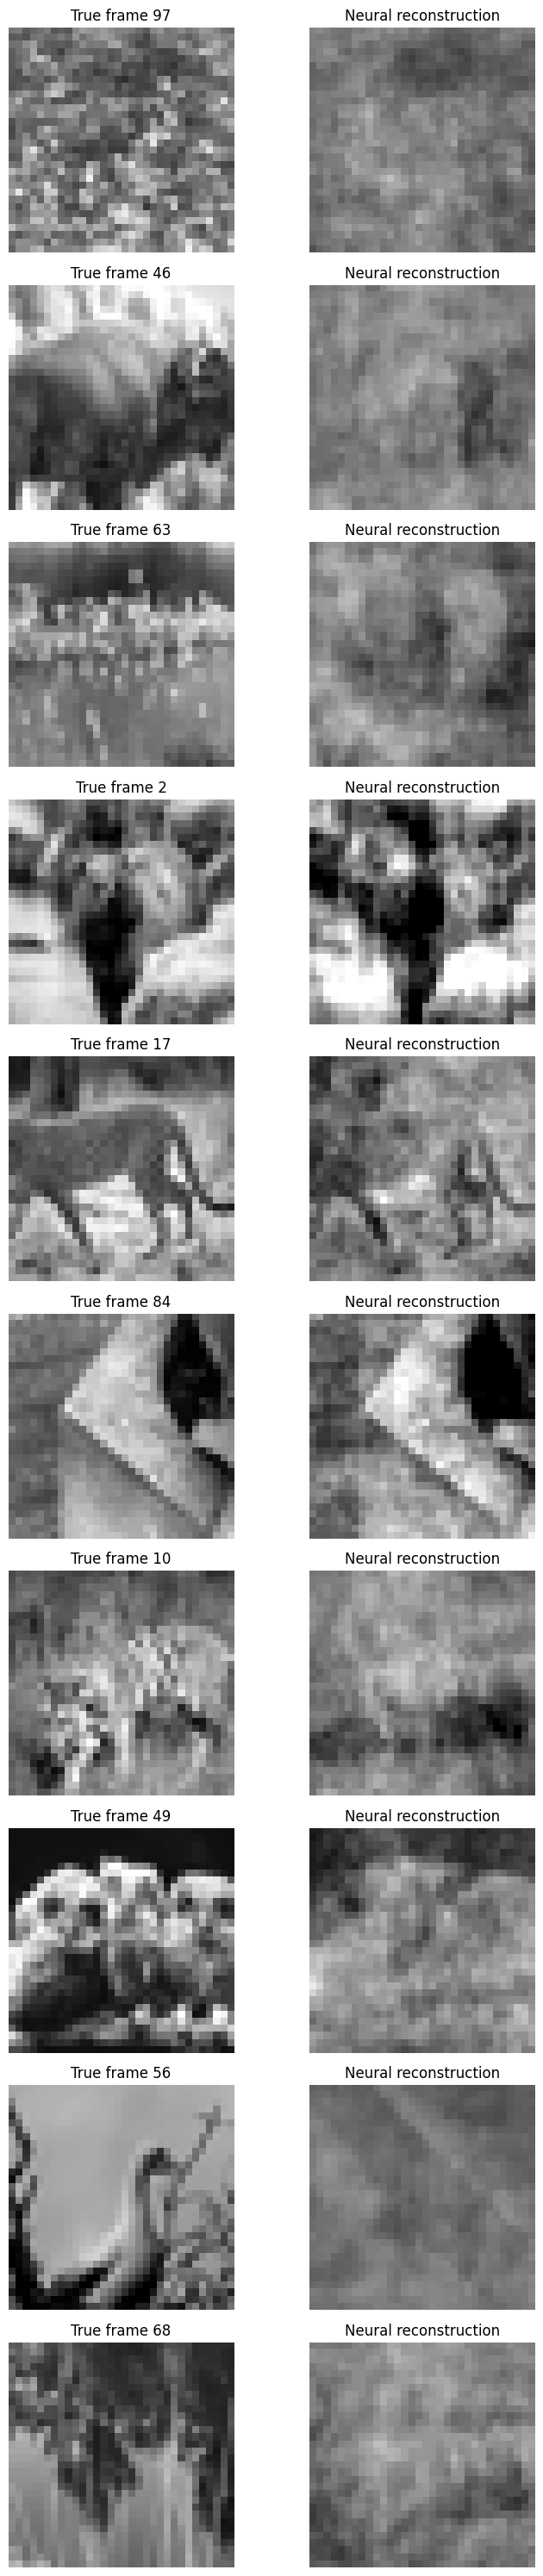

In [357]:
import matplotlib.pyplot as plt
import numpy as np

example_indices = np.random.default_rng(42).choice(
    len(y_test),
    size=10,
    replace=False
)

fig, axes = plt.subplots(10, 2, figsize=(8, 30))

for row, idx in enumerate(example_indices):
    frame_id = int(y_test[idx])

    axes[row, 0].imshow(
        true_test_images[idx],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title(f"True frame {frame_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        reconstructed_images[idx],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 1].set_title("Neural reconstruction")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [358]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(
    true_test_images.reshape(len(true_test_images), -1),
    reconstructed_images.reshape(len(reconstructed_images), -1)
)

correlations = []

for true_image, reconstructed_image in zip(
    true_test_images,
    reconstructed_images
):
    correlation = np.corrcoef(
        true_image.ravel(),
        reconstructed_image.ravel()
    )[0, 1]
    correlations.append(correlation)

correlations = np.asarray(correlations)

print(f"Pixel MSE: {mse:.4f}")
print(f"Mean correlation: {np.nanmean(correlations):.4f}")
print(f"Median correlation: {np.nanmedian(correlations):.4f}")
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    Y_pred,
    scene_pca_features
)

retrieved_frames = np.argmax(similarities, axis=1)

retrieval_accuracy = np.mean(
    retrieved_frames == y_test
)

print(f"PCA retrieval accuracy: {retrieval_accuracy:.4f}")

Pixel MSE: 0.0340
Mean correlation: 0.5786
Median correlation: 0.6841
PCA retrieval accuracy: 0.6034


In [359]:
pca_component_correlations = []

for component in range(Y_test.shape[1]):

    corr = np.corrcoef(
        Y_test[:, component],
        Y_pred[:, component]
    )[0, 1]

    pca_component_correlations.append(corr)

pca_component_correlations = np.asarray(
    pca_component_correlations
)

print(
    "Mean PCA component correlation:",
    np.nanmean(pca_component_correlations)
)

print(
    "Median PCA component correlation:",
    np.nanmedian(pca_component_correlations)
)

Mean PCA component correlation: 0.6039471413535936
Median PCA component correlation: 0.6028473625362369


# VAE reconstruction experiment

In [360]:

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.13.0
Device: cpu


In [361]:
# Prepare images for VAE

vae_images = torch.tensor(
    small_scene_images[:, None, :, :],
    dtype=torch.float32
)#image channel x height x width

print("VAE image tensor shape:", vae_images.shape)
print("Minimum:", vae_images.min().item())
print("Maximum:", vae_images.max().item())

VAE image tensor shape: torch.Size([118, 1, 32, 32])
Minimum: 0.0
Maximum: 1.0


In [362]:
LATENT_DIM = 32


class VAE(nn.Module):

    def __init__(self, latent_dim=32):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(

            # 1 x 32 x 32
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 16 x 16 x 16
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 32 x 8 x 8
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(
            32 * 8 * 8,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            32 * 8 * 8,
            latent_dim
        )

        # Decoder
        self.fc_decode = nn.Linear(
            latent_dim,
            32 * 8 * 8
        )

        self.decoder = nn.Sequential(

            # 32 x 8 x 8
            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 16 x 16 x 16
            nn.ConvTranspose2d(
                16,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            # output in [0, 1]
            nn.Sigmoid()
        )

    def encode(self, x):

        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        h = self.fc_decode(z)

        h = h.view(
            -1,
            32,
            8,
            8
        )

        return self.decoder(h)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar


vae = VAE(
    latent_dim=LATENT_DIM
).to(device)

print(vae)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=2048, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=2048, out_features=32, bias=True)
  (fc_decode): Linear(in_features=32, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [363]:
#VAE loss

BETA = 1e-3


def vae_loss(
    reconstructed,
    original,
    mu,
    logvar,
    beta=BETA
):

    reconstruction_loss = F.mse_loss(
        reconstructed,
        original,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

In [364]:
# VAE training data

vae_dataset = TensorDataset(
    vae_images
)

vae_loader = DataLoader(
    vae_dataset,
    batch_size=16,
    shuffle=True
)

print("Number of unique images:", len(vae_dataset))
print("Number of batches:", len(vae_loader))

Number of unique images: 118
Number of batches: 8


In [365]:
# Train VAE

optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

N_EPOCHS = 300

vae_loss_history = []
vae_recon_history = []
vae_kl_history = []


for epoch in range(N_EPOCHS):

    vae.train()

    total_epoch_loss = 0.0
    total_recon_loss = 0.0
    total_kl_loss = 0.0

    for (images,) in vae_loader:

        images = images.to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = vae(
            images
        )

        (
            loss,
            recon_loss,
            kl_loss
        ) = vae_loss(
            reconstructed,
            images,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_epoch_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()

    mean_loss = (
        total_epoch_loss
        / len(vae_loader)
    )

    mean_recon = (
        total_recon_loss
        / len(vae_loader)
    )

    mean_kl = (
        total_kl_loss
        / len(vae_loader)
    )

    vae_loss_history.append(mean_loss)
    vae_recon_history.append(mean_recon)
    vae_kl_history.append(mean_kl)

    if (
        epoch % 25 == 0
        or epoch == N_EPOCHS - 1
    ):

        print(
            f"Epoch {epoch:3d} | "
            f"total={mean_loss:.5f} | "
            f"recon={mean_recon:.5f} | "
            f"KL={mean_kl:.5f}"
        )

Epoch   0 | total=0.06139 | recon=0.06135 | KL=0.04667
Epoch  25 | total=0.02262 | recon=0.02069 | KL=1.93489
Epoch  50 | total=0.01680 | recon=0.01458 | KL=2.22055
Epoch  75 | total=0.01319 | recon=0.01076 | KL=2.42782
Epoch 100 | total=0.01072 | recon=0.00825 | KL=2.46622
Epoch 125 | total=0.00921 | recon=0.00669 | KL=2.52083
Epoch 150 | total=0.00832 | recon=0.00575 | KL=2.56195
Epoch 175 | total=0.00764 | recon=0.00515 | KL=2.48650
Epoch 200 | total=0.00701 | recon=0.00455 | KL=2.45594
Epoch 225 | total=0.00670 | recon=0.00425 | KL=2.45687
Epoch 250 | total=0.00635 | recon=0.00383 | KL=2.51488
Epoch 275 | total=0.00627 | recon=0.00382 | KL=2.45371
Epoch 299 | total=0.00596 | recon=0.00349 | KL=2.47369


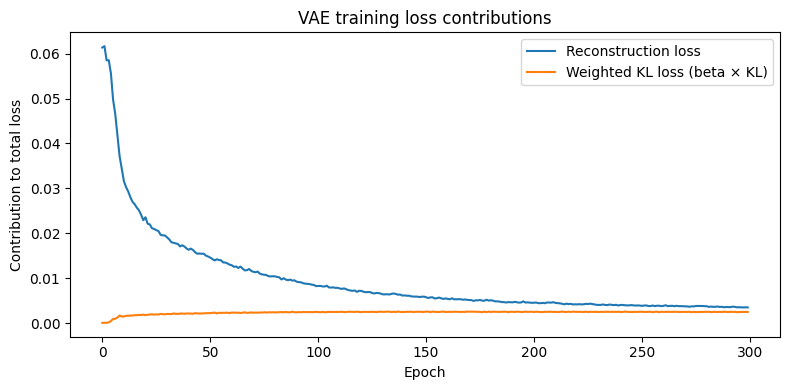

In [366]:
# Plot VAE training history

plt.figure(figsize=(8, 4))

plt.plot(
    vae_recon_history,
    label="Reconstruction loss"
)

plt.plot(
    np.array(vae_kl_history) * BETA,
    label="Weighted KL loss (beta × KL)"
)

plt.xlabel("Epoch")
plt.ylabel("Contribution to total loss")
plt.title("VAE training loss contributions")
plt.legend()

plt.tight_layout()
plt.show()

In [367]:
# Reconstruct the 118 images using only the VAE

vae.eval()

with torch.no_grad():

    all_images = vae_images.to(device)

    mu, logvar = vae.encode(
        all_images
    )

    vae_image_reconstructions = vae.decode(
        mu
    )

vae_image_reconstructions = (
    vae_image_reconstructions
    .cpu()
    .numpy()
    [:, 0]
)

print(
    "VAE reconstruction shape:",
    vae_image_reconstructions.shape
)

VAE reconstruction shape: (118, 32, 32)


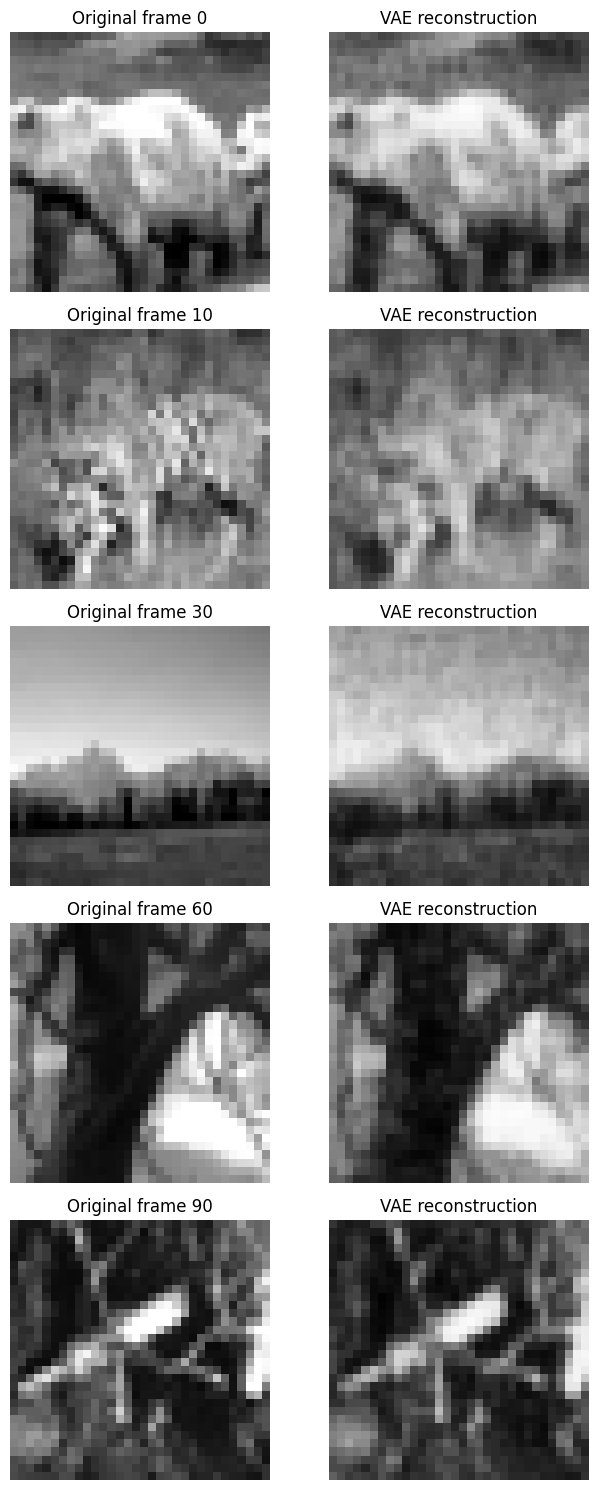

In [368]:
# Original image vs VAE-only reconstruction

frame_ids = [
    0,
    10,
    30,
    60,
    90
]

fig, axes = plt.subplots(
    len(frame_ids),
    2,
    figsize=(7, 3 * len(frame_ids))
)

for row, frame_id in enumerate(frame_ids):

    # Original
    axes[row, 0].imshow(
        small_scene_images[frame_id],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 0].set_title(
        f"Original frame {frame_id}"
    )

    axes[row, 0].axis("off")

    # VAE
    axes[row, 1].imshow(
        vae_image_reconstructions[frame_id],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        "VAE reconstruction"
    )

    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [369]:
# Evaluate image -> VAE -> image

from sklearn.metrics import mean_squared_error

vae_only_mse = mean_squared_error(
    small_scene_images.reshape(118, -1),
    vae_image_reconstructions.reshape(118, -1)
)

vae_only_correlations = []

for true_image, vae_image in zip(
    small_scene_images,
    vae_image_reconstructions
):

    corr = np.corrcoef(
        true_image.ravel(),
        vae_image.ravel()
    )[0, 1]

    vae_only_correlations.append(corr)

vae_only_correlations = np.asarray(
    vae_only_correlations
)

print(
    f"VAE-only MSE: "
    f"{vae_only_mse:.4f}"
)

print(
    f"VAE-only mean correlation: "
    f"{np.nanmean(vae_only_correlations):.4f}"
)

print(
    f"VAE-only median correlation: "
    f"{np.nanmedian(vae_only_correlations):.4f}"
)

VAE-only MSE: 0.0029
VAE-only mean correlation: 0.9684
VAE-only median correlation: 0.9734


In [370]:
# Extract deterministic VAE latent representations

vae.eval()

with torch.no_grad():

    scene_vae_latents, _ = vae.encode(
        vae_images.to(device)
    )

scene_vae_latents = (
    scene_vae_latents
    .cpu()
    .numpy()
)

print(
    "VAE latent feature shape:",
    scene_vae_latents.shape
)

VAE latent feature shape: (118, 32)


In [371]:
# Neural trial -> corresponding VAE latent target

Y_train_vae = (
    scene_vae_latents[y_train]
)

Y_test_vae = (
    scene_vae_latents[y_test]
)

print(
    "Neural training input:",
    X_train.shape
)

print(
    "VAE training target:",
    Y_train_vae.shape
)

print(
    "Neural testing input:",
    X_test.shape
)

print(
    "VAE testing target:",
    Y_test_vae.shape
)

Neural training input: (4720, 216)
VAE training target: (4720, 32)
Neural testing input: (1180, 216)
VAE testing target: (1180, 32)


In [372]:
# Scale VAE latent targets

from sklearn.preprocessing import StandardScaler

vae_target_scaler = StandardScaler()

Y_train_vae_scaled = (
    vae_target_scaler.fit_transform(
        Y_train_vae
    )
)

Y_test_vae_scaled = (
    vae_target_scaler.transform(
        Y_test_vae
    )
)

print(
    "Scaled VAE target shape:",
    Y_train_vae_scaled.shape
)

Scaled VAE target shape: (4720, 32)


In [379]:
# Freeze the pretrained VAE
vae.eval()

for param in vae.parameters():
    param.requires_grad = False

print("VAE frozen.")

VAE frozen.


In [373]:
# Neural activity -> VAE latent

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

vae_neural_model = Pipeline([
    (
        "neural_scaler",
        StandardScaler()
    ),
    (
        "mlp",
        MLPRegressor(
            hidden_layer_sizes=(
                512,
                256,
                128
            ),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=5e-4,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=30,
            random_state=42,
            verbose=True
        )
    )
])

vae_neural_model.fit(
    X_train,
    Y_train_vae_scaled
)

Iteration 1, loss = 0.52765226
Validation score: 0.017914
Iteration 2, loss = 0.47118111
Validation score: 0.068025
Iteration 3, loss = 0.43489935
Validation score: 0.119551
Iteration 4, loss = 0.39788224
Validation score: 0.168324
Iteration 5, loss = 0.36465382
Validation score: 0.202274
Iteration 6, loss = 0.33661121
Validation score: 0.227527
Iteration 7, loss = 0.31227560
Validation score: 0.247181
Iteration 8, loss = 0.29118035
Validation score: 0.264459
Iteration 9, loss = 0.27245481
Validation score: 0.276639
Iteration 10, loss = 0.25570810
Validation score: 0.287028
Iteration 11, loss = 0.24018853
Validation score: 0.295205
Iteration 12, loss = 0.22586008
Validation score: 0.302879
Iteration 13, loss = 0.21292273
Validation score: 0.304405
Iteration 14, loss = 0.20117707
Validation score: 0.312874
Iteration 15, loss = 0.18982958
Validation score: 0.313700
Iteration 16, loss = 0.17956518
Validation score: 0.317685
Iteration 17, loss = 0.17014158
Validation score: 0.318358
Iterat

,steps,"[('neural_scaler', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"(512, ...)"
,activation,'relu'
,solver,'adam'


In [374]:
# Predict VAE latent representation from neural activity

Y_pred_vae_scaled = (
    vae_neural_model.predict(
        X_test
    )
)

Y_pred_vae = (
    vae_target_scaler
    .inverse_transform(
        Y_pred_vae_scaled
    )
)

print(
    "Predicted VAE latent shape:",
    Y_pred_vae.shape
)

mlp_vae = (
    vae_neural_model
    .named_steps["mlp"]
)

print(
    "Training iterations:",
    mlp_vae.n_iter_
)

print(
    "Final training loss:",
    mlp_vae.loss_
)

print(
    "Best validation score:",
    mlp_vae.best_validation_score_
)

Predicted VAE latent shape: (1180, 32)
Training iterations: 50
Final training loss: 0.0417059008446255
Best validation score: 0.31879389538336267


In [375]:
# VAE latent -> reconstructed image

predicted_vae_latents_tensor = torch.tensor(
    Y_pred_vae,
    dtype=torch.float32
).to(device)

vae.eval()

with torch.no_grad():

    neural_vae_reconstructions = vae.decode(
        predicted_vae_latents_tensor
    )

neural_vae_reconstructions = (
    neural_vae_reconstructions
    .cpu()
    .numpy()
    [:, 0]
)

print(
    "Neural VAE reconstruction shape:",
    neural_vae_reconstructions.shape
)

Neural VAE reconstruction shape: (1180, 32, 32)


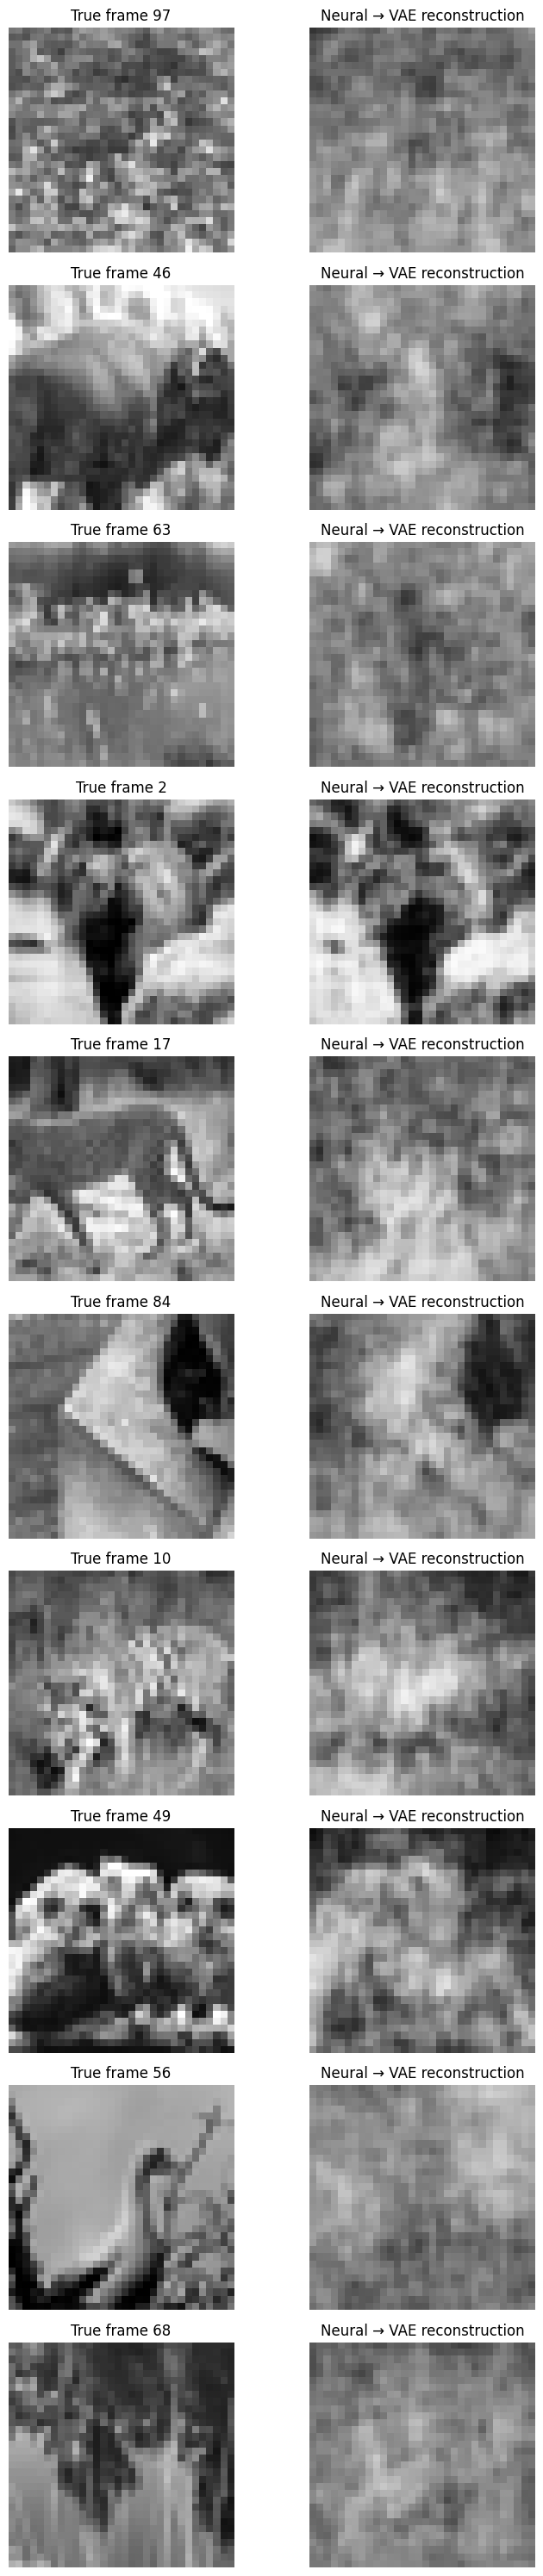

In [376]:
# Compare true image with VAE neural reconstruction

fig, axes = plt.subplots(
    10,
    2,
    figsize=(8, 30)
)

for row, idx in enumerate(example_indices):

    frame_id = int(
        y_test[idx]
    )

    # True image
    axes[row, 0].imshow(
        true_test_images[idx],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 0].set_title(
        f"True frame {frame_id}"
    )

    axes[row, 0].axis("off")

    # Neural -> VAE
    axes[row, 1].imshow(
        neural_vae_reconstructions[idx],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        "Neural → VAE reconstruction"
    )

    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [377]:
# Evaluate neural -> VAE reconstruction

vae_neural_mse = mean_squared_error(
    true_test_images.reshape(
        len(true_test_images),
        -1
    ),
    neural_vae_reconstructions.reshape(
        len(neural_vae_reconstructions),
        -1
    )
)

vae_neural_correlations = []

for true_image, reconstructed_image in zip(
    true_test_images,
    neural_vae_reconstructions
):

    corr = np.corrcoef(
        true_image.ravel(),
        reconstructed_image.ravel()
    )[0, 1]

    vae_neural_correlations.append(
        corr
    )

vae_neural_correlations = np.asarray(
    vae_neural_correlations
)

print(
    f"VAE Pixel MSE: "
    f"{vae_neural_mse:.4f}"
)

print(
    f"VAE Mean correlation: "
    f"{np.nanmean(vae_neural_correlations):.4f}"
)

print(
    f"VAE Median correlation: "
    f"{np.nanmedian(vae_neural_correlations):.4f}"
)

VAE Pixel MSE: 0.0433
VAE Mean correlation: 0.4890
VAE Median correlation: 0.5268


In [378]:
# Predictability of each VAE latent dimension

vae_latent_correlations = []

for dim in range(Y_test_vae.shape[1]):

    corr = np.corrcoef(
        Y_test_vae[:, dim],
        Y_pred_vae[:, dim]
    )[0, 1]

    vae_latent_correlations.append(corr)

vae_latent_correlations = np.array(
    vae_latent_correlations
)

print("Latent correlations:")
print(vae_latent_correlations)

print()
print(
    "Mean latent correlation:",
    np.nanmean(vae_latent_correlations)
)

print(
    "Median latent correlation:",
    np.nanmedian(vae_latent_correlations)
)

Latent correlations:
[0.59317044 0.60965121 0.52785471 0.60021746 0.62920458 0.58187624
 0.54453157 0.5560643  0.55296998 0.61551954 0.60377319 0.65718297
 0.57987137 0.58149163 0.58868971 0.56640066 0.57526473 0.62807775
 0.57272963 0.61367478 0.59171842 0.53496896 0.61434412 0.59679132
 0.58589573 0.55546521 0.60233914 0.60225441 0.56043044 0.62251161
 0.49009845 0.58795734]

Mean latent correlation: 0.5850934882758028
Median latent correlation: 0.588323525203021


In [380]:
from sklearn.preprocessing import StandardScaler

neural_scaler = StandardScaler()

X_train_nn = neural_scaler.fit_transform(X_train)
X_test_nn = neural_scaler.transform(X_test)

X_train_nn = torch.tensor(
    X_train_nn,
    dtype=torch.float32
)

X_test_nn = torch.tensor(
    X_test_nn,
    dtype=torch.float32
)

print(X_train_nn.shape)
print(X_test_nn.shape)

torch.Size([4720, 216])
torch.Size([1180, 216])


In [385]:
Y_train_latent_nn = torch.tensor(
    Y_train_vae,
    dtype=torch.float32
)

Y_test_latent_nn = torch.tensor(
    Y_test_vae,
    dtype=torch.float32
)

print(Y_train_latent_nn.shape)

torch.Size([4720, 32])


In [386]:
train_target_images = torch.tensor(
    small_scene_images[y_train],
    dtype=torch.float32
).unsqueeze(1)

test_target_images = torch.tensor(
    small_scene_images[y_test],
    dtype=torch.float32
).unsqueeze(1)

print(train_target_images.shape)
print(test_target_images.shape)

torch.Size([4720, 1, 32, 32])
torch.Size([1180, 1, 32, 32])


In [387]:
class NeuralToLatent(nn.Module):

    def __init__(
        self,
        input_dim=216,
        latent_dim=32
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

In [388]:
neural_encoder = NeuralToLatent(
    input_dim=X_train.shape[1],
    latent_dim=LATENT_DIM
).to(device)

print(neural_encoder)

NeuralToLatent(
  (net): Sequential(
    (0): Linear(in_features=216, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=32, bias=True)
  )
)


In [389]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_nn,
    Y_train_latent_nn,
    train_target_images
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

print("Training batches:", len(train_loader))

Training batches: 74


In [391]:
latent_loss_fn = nn.MSELoss()
image_loss_fn = nn.MSELoss()

LAMBDA_IMAGE = 1.0
total_loss = latent_loss + LAMBDA_IMAGE * image_loss

NameError: name 'latent_loss' is not defined

In [390]:
optimizer = torch.optim.Adam(
    neural_encoder.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

N_EPOCHS = 200

total_history = []
latent_history = []
image_history = []

for epoch in range(N_EPOCHS):

    neural_encoder.train()

    running_total = 0.0
    running_latent = 0.0
    running_image = 0.0

    for (
        neural_batch,
        latent_batch,
        image_batch
    ) in train_loader:

        neural_batch = neural_batch.to(device)
        latent_batch = latent_batch.to(device)
        image_batch = image_batch.to(device)

        optimizer.zero_grad()

        # Neural activity -> predicted latent
        predicted_latent = neural_encoder(
            neural_batch
        )

        # Latent accuracy
        latent_loss = latent_loss_fn(
            predicted_latent,
            latent_batch
        )

        # Predicted latent -> frozen VAE decoder -> image
        predicted_image = vae.decode(
            predicted_latent
        )

        # Image reconstruction accuracy
        image_loss = image_loss_fn(
            predicted_image,
            image_batch
        )

        total_loss = (
            latent_loss
            +
            LAMBDA_IMAGE * image_loss
        )

        total_loss.backward()

        optimizer.step()

        running_total += total_loss.item()
        running_latent += latent_loss.item()
        running_image += image_loss.item()

    total_history.append(
        running_total / len(train_loader)
    )

    latent_history.append(
        running_latent / len(train_loader)
    )

    image_history.append(
        running_image / len(train_loader)
    )

    if (
        epoch == 0
        or (epoch + 1) % 20 == 0
    ):
        print(
            f"Epoch {epoch+1:3d} | "
            f"Total: {total_history[-1]:.5f} | "
            f"Latent: {latent_history[-1]:.5f} | "
            f"Image: {image_history[-1]:.5f}"
        )

NameError: name 'latent_loss_fn' is not defined